In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import warnings

warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({'font.size': fsize})
%config InlineBackend.figure_format = 'retina'

# LLM Marker Selection Analysis

Compares named selection, anonymous selection, extraction, and generation against human curation.

Named selection: LLM sees cell type names + top N DEGs.  
Anonymous selection: LLM sees CLUSTER 1..K + top N DEGs (no cell type names).  
Sweep: N = 10, 20, 30, 40, 50, 100, 200, 300, 400, 500.

# Load data

In [2]:
datasets = [
    'adipose_Emont2022',
    'adipose_Hildreth2021',
    'bone_He2021',
    'eye_Gautam2021',
    'lung_Adams2020',
    'ovary_Wagner2020',
    'testis_Shamis2020',
]

labels = {
    'adipose_Emont2022': 'Adipose (Emont)',
    'adipose_Hildreth2021': 'Adipose (Hildreth)',
    'bone_He2021': 'Bone (He)',
    'eye_Gautam2021': 'Eye (Gautam)',
    'lung_Adams2020': 'Lung (Adams)',
    'ovary_Wagner2020': 'Ovary (Wagner)',
    'testis_Shamis2020': 'Testis (Shamis)',
}

N_values = [10, 20, 30, 40, 50, 100, 200, 300, 400, 500]

LLM_FILENAME = 'extracted_txt_rerun.json'
LLM_FALLBACK = 'extracted_txt.json'

def load_and_norm(path):
    df = pd.read_json(path)
    df['group_name'] = df['group_name'].str.strip().str.upper()
    df['feature_name'] = df['feature_name'].str.strip().str.upper()
    return df


def fill_feature_ids_from_name(df, refs):
    """Fill missing feature_id values via unambiguous feature_name -> Ensembl mapping."""
    out = df.copy()
    out['feature_id'] = out['feature_id'].astype('object')
    out['feature_name_norm'] = out['feature_name'].astype(str).str.strip().str.upper()

    ref = pd.concat(refs, ignore_index=True)
    ref = ref.dropna(subset=['feature_name', 'feature_id']).copy()
    ref['feature_name_norm'] = ref['feature_name'].astype(str).str.strip().str.upper()

    uniq = ref[['feature_name_norm', 'feature_id']].drop_duplicates()
    counts = uniq.groupby('feature_name_norm')['feature_id'].nunique()
    one_to_one_names = counts[counts == 1].index
    name_to_id = (
        uniq[uniq['feature_name_norm'].isin(one_to_one_names)]
        .drop_duplicates('feature_name_norm')
        .set_index('feature_name_norm')['feature_id']
    )

    missing = out['feature_id'].isna() | (out['feature_id'] == '')
    out.loc[missing, 'feature_id'] = out.loc[missing, 'feature_name_norm'].map(name_to_id)
    return out.drop(columns=['feature_name_norm'])

data = {}
for ds in datasets:
    base = Path(f'../data/{ds}')
    hmn = load_and_norm(base / 'evidence_human' / 'extracted.json')
    deg = load_and_norm(base / 'evidence_deg' / 'extracted.json')
    gen = load_and_norm(base / 'evidence_generated' / 'extracted.json')
    llm_path = base / 'evidence_llm' / LLM_FILENAME
    if not llm_path.exists():
        llm_path = base / 'evidence_llm' / LLM_FALLBACK
    llm = load_and_norm(llm_path)
    llm = fill_feature_ids_from_name(llm, [hmn, deg, gen])

    sel, sel_anon = {}, {}
    for n in N_values:
        p = base / 'evidence_selected' / f'selected_top{n}.json'
        if p.exists():
            sel[n] = load_and_norm(p)
        pa = base / 'evidence_selected' / f'selected_anon_top{n}.json'
        if pa.exists():
            sel_anon[n] = load_and_norm(pa)

    data[ds] = {'hmn': hmn, 'deg': deg, 'gen': gen, 'llm': llm, 'sel': sel, 'sel_anon': sel_anon}
    print(f'{labels[ds]}: hmn={len(hmn)}, named N={sorted(sel.keys())}, anon N={sorted(sel_anon.keys())}')

Adipose (Emont): hmn=387, named N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500], anon N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500]


Adipose (Hildreth): hmn=301, named N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500], anon N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500]
Bone (He): hmn=825, named N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500], anon N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500]


Eye (Gautam): hmn=514, named N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500], anon N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500]


Lung (Adams): hmn=147, named N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500], anon N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500]
Ovary (Wagner): hmn=139, named N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500], anon N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500]


Testis (Shamis): hmn=215, named N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500], anon N=[10, 20, 30, 40, 50, 100, 200, 300, 400, 500]


# Helpers

In [3]:
def build_pairs(df):
    pairs = set()
    for _, r in df.iterrows():
        gn, fn = r.get('group_name'), r.get('feature_id')
        if pd.notna(gn) and pd.notna(fn) and gn and fn:
            pairs.add((gn, fn))
    return pairs


def build_groups(df):
    groups = {}
    for _, r in df.iterrows():
        gn, fn = r.get('group_name'), r.get('feature_id')
        if pd.notna(gn) and pd.notna(fn) and gn and fn:
            groups.setdefault(gn, set()).add(fn)
    return groups


def pair_metrics(pairs_a, pairs_b):
    """Precision, recall, F1 of pairs_a vs pairs_b (b = reference)."""
    if not pairs_a and not pairs_b:
        return 0, 0, 0
    tp = len(pairs_a & pairs_b)
    p = tp / len(pairs_a) if pairs_a else 0
    r = tp / len(pairs_b) if pairs_b else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    return p, r, f


def per_celltype_gene_f1(groups_a, groups_b):
    """Mean per-cell-type gene F1 over shared cell types."""
    shared = set(groups_a) & set(groups_b)
    if not shared:
        return 0, 0
    f1s = []
    for ct in shared:
        a, b = groups_a[ct], groups_b[ct]
        tp = len(a & b)
        p = tp / len(a) if a else 0
        r = tp / len(b) if b else 0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0
        f1s.append(f)
    return np.mean(f1s), len(shared)


def gene_jaccard(groups_a, groups_b):
    ga = set(fn for fns in groups_a.values() for fn in fns)
    gb = set(fn for fns in groups_b.values() for fn in fns)
    union = ga | gb
    return len(ga & gb) / len(union) if union else 0


def upper_bound_recall(hmn_pairs, deg_df, top_n):
    """Fraction of human pairs present in top N DEGs."""
    deg_top = deg_df[deg_df['metrics_rank'] <= top_n]
    deg_pairs = build_pairs(deg_top)
    if not hmn_pairs:
        return 0
    return len(hmn_pairs & deg_pairs) / len(hmn_pairs)

# Compute sweep metrics (named + anonymous)

In [4]:
sweep_rows = []

for ds in datasets:
    d = data[ds]
    hmn_pairs = build_pairs(d['hmn'])
    hmn_groups = build_groups(d['hmn'])

    for mode, sel_dict in [('named', d['sel']), ('anon', d['sel_anon'])]:
        for n in N_values:
            if n not in sel_dict:
                continue
            sel_df = sel_dict[n]
            sel_pairs = build_pairs(sel_df)
            sel_groups = build_groups(sel_df)

            p_prec, p_rec, p_f1 = pair_metrics(sel_pairs, hmn_pairs)
            ct_f1, ct_shared = per_celltype_gene_f1(sel_groups, hmn_groups)
            g_jacc = gene_jaccard(sel_groups, hmn_groups)
            ub_recall = upper_bound_recall(hmn_pairs, d['deg'], n)

            sweep_rows.append({
                'dataset': ds, 'label': labels[ds], 'mode': mode, 'N': n,
                'n_selected': len(sel_pairs),
                'pair_precision': p_prec, 'pair_recall': p_rec, 'pair_f1': p_f1,
                'gene_f1': ct_f1, 'gene_jaccard': g_jacc,
                'upper_bound_recall': ub_recall, 'ct_shared': ct_shared,
            })

sweep = pd.DataFrame(sweep_rows)
print(f'{len(sweep)} rows: {sweep["mode"].value_counts().to_dict()}')

140 rows: {'named': 70, 'anon': 70}


# Figure 1: Selection performance vs N

Named selection: pair F1, precision, recall, and upper bound recall as a function of N.

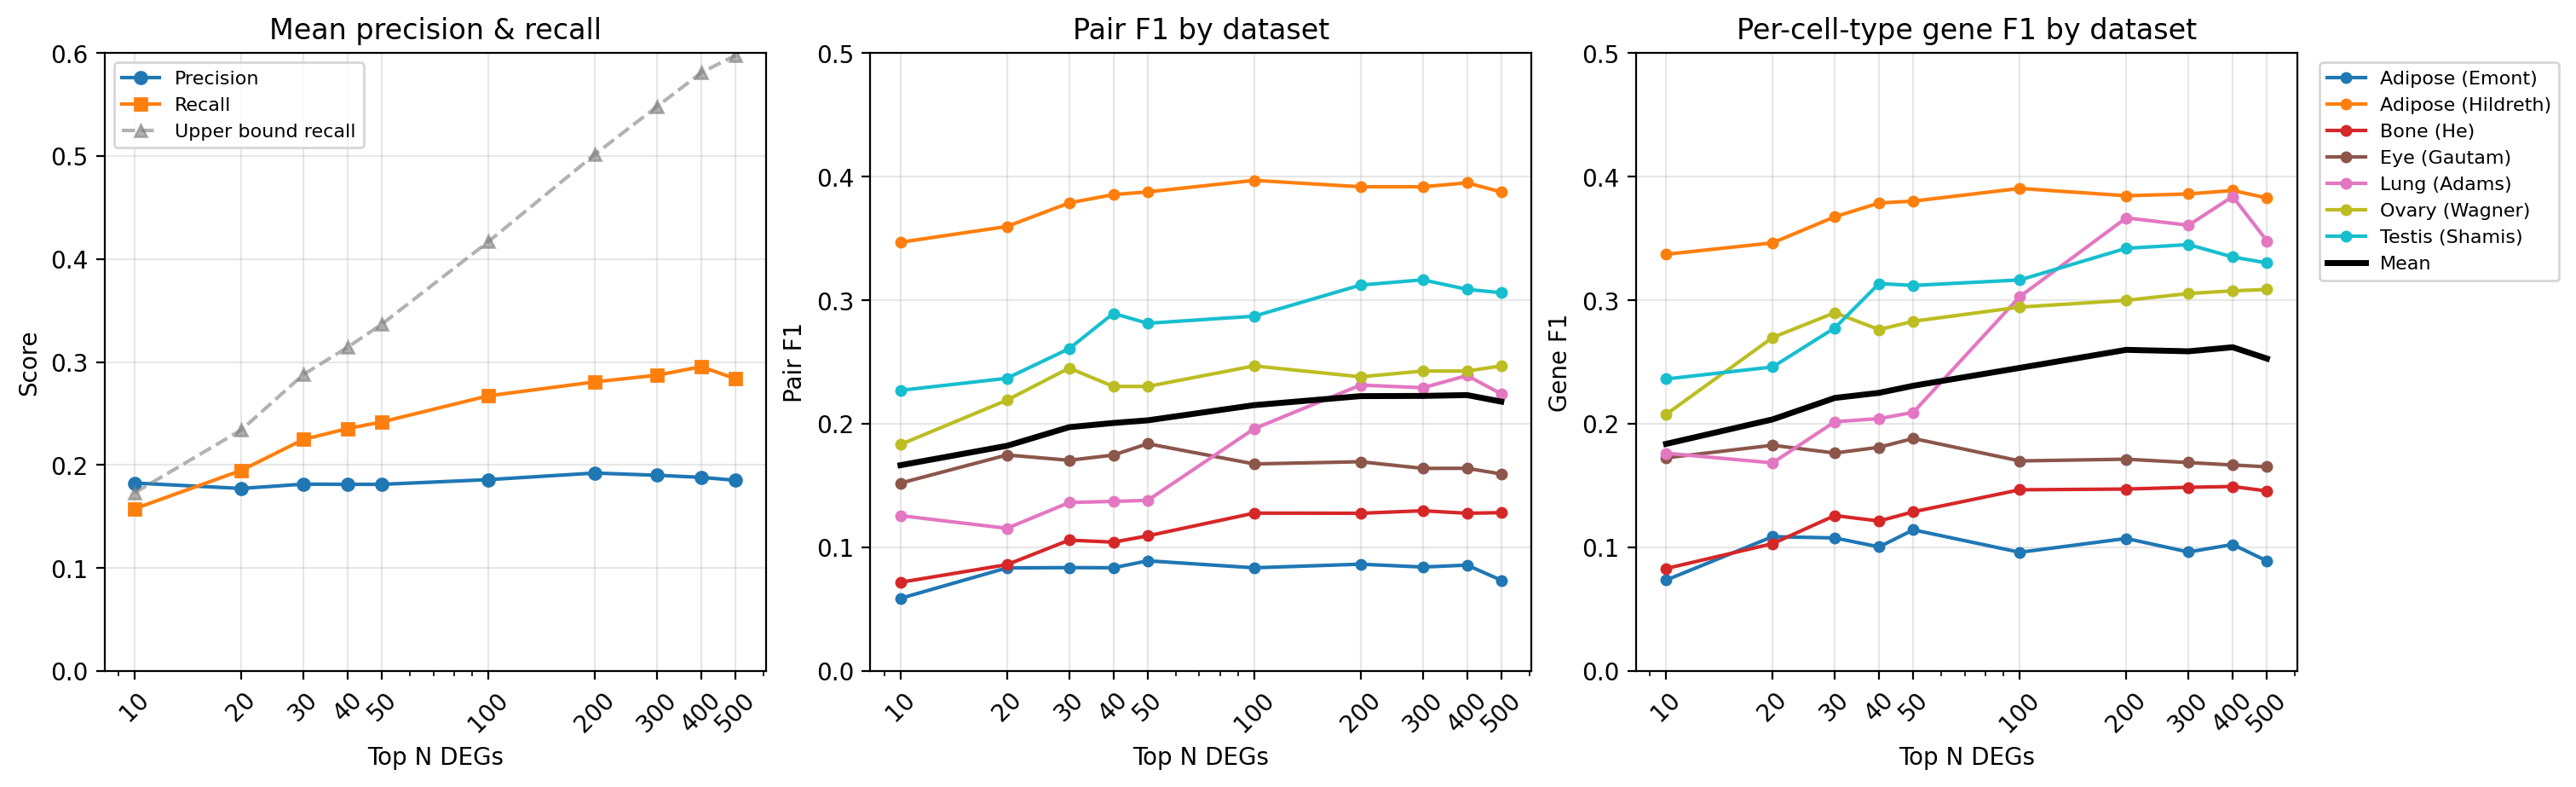

In [5]:
named = sweep[sweep['mode'] == 'named']
colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# Panel a: Mean precision, recall, upper bound
ax = axes[0]
mean_n = named.groupby('N')[['pair_precision', 'pair_recall', 'upper_bound_recall']].mean().reset_index()
ax.plot(mean_n['N'], mean_n['pair_precision'], 'o-', color='tab:blue', label='Precision', markersize=5)
ax.plot(mean_n['N'], mean_n['pair_recall'], 's-', color='tab:orange', label='Recall', markersize=5)
ax.plot(mean_n['N'], mean_n['upper_bound_recall'], '^--', color='gray', alpha=0.6, label='Upper bound recall', markersize=5)
ax.set(xlabel='Top N DEGs', ylabel='Score', title='Mean precision & recall')
ax.set_xscale('log')
ax.set_xticks(N_values)
ax.set_xticklabels([str(n) for n in N_values], rotation=45)
ax.set_ylim(0, 0.6)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel b: Pair F1 per dataset
ax = axes[1]
for i, ds in enumerate(datasets):
    sub = named[named['dataset'] == ds].sort_values('N')
    ax.plot(sub['N'], sub['pair_f1'], 'o-', color=colors[i], label=labels[ds], markersize=4)
mean_f1 = named.groupby('N')['pair_f1'].mean().reset_index()
ax.plot(mean_f1['N'], mean_f1['pair_f1'], 'k-', linewidth=2.5, label='Mean', zorder=10)
ax.set(xlabel='Top N DEGs', ylabel='Pair F1', title='Pair F1 by dataset')
ax.set_xscale('log')
ax.set_xticks(N_values)
ax.set_xticklabels([str(n) for n in N_values], rotation=45)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)

# Panel c: Gene F1 per dataset
ax = axes[2]
for i, ds in enumerate(datasets):
    sub = named[named['dataset'] == ds].sort_values('N')
    ax.plot(sub['N'], sub['gene_f1'], 'o-', color=colors[i], label=labels[ds], markersize=4)
mean_gf1 = named.groupby('N')['gene_f1'].mean().reset_index()
ax.plot(mean_gf1['N'], mean_gf1['gene_f1'], 'k-', linewidth=2.5, label='Mean', zorder=10)
ax.set(xlabel='Top N DEGs', ylabel='Gene F1', title='Per-cell-type gene F1 by dataset')
ax.set_xscale('log')
ax.set_xticks(N_values)
ax.set_xticklabels([str(n) for n in N_values], rotation=45)
ax.set_ylim(0, 0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.savefig('figures/fig_selection_sweep.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Figure 2: Named vs anonymous selection

Does knowing the cell type name help the LLM select better markers?

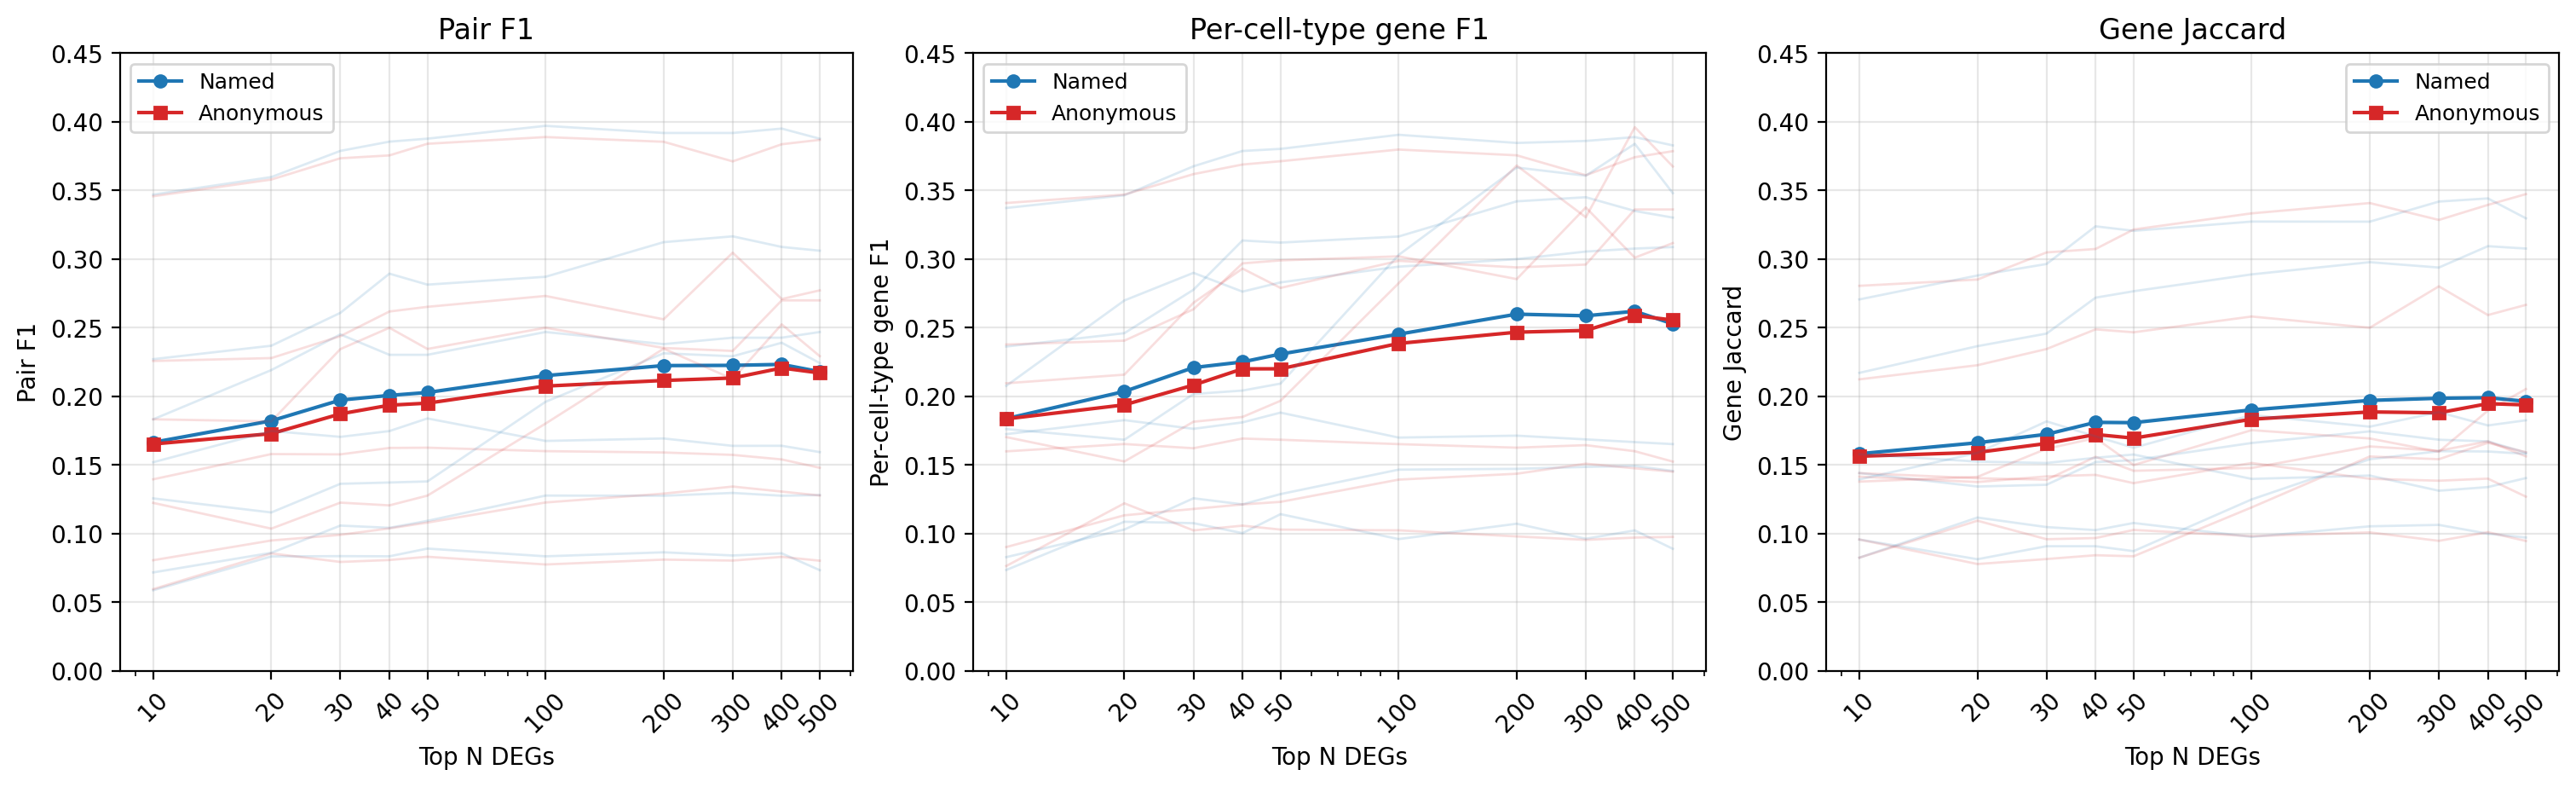

In [6]:
# Pivot to compare named vs anon side by side
named_mean = sweep[sweep['mode'] == 'named'].groupby('N')[['pair_f1', 'gene_f1', 'gene_jaccard', 'n_selected']].mean().reset_index()
anon_mean = sweep[sweep['mode'] == 'anon'].groupby('N')[['pair_f1', 'gene_f1', 'gene_jaccard', 'n_selected']].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

for metric, ax, title in zip(
    ['pair_f1', 'gene_f1', 'gene_jaccard'],
    axes,
    ['Pair F1', 'Per-cell-type gene F1', 'Gene Jaccard'],
):
    ax.plot(named_mean['N'], named_mean[metric], 'o-', color='tab:blue', label='Named', markersize=5)
    ax.plot(anon_mean['N'], anon_mean[metric], 's-', color='tab:red', label='Anonymous', markersize=5)

    # Per-dataset traces (faint)
    for i, ds in enumerate(datasets):
        sub_n = sweep[(sweep['dataset'] == ds) & (sweep['mode'] == 'named')].sort_values('N')
        sub_a = sweep[(sweep['dataset'] == ds) & (sweep['mode'] == 'anon')].sort_values('N')
        ax.plot(sub_n['N'], sub_n[metric], '-', color='tab:blue', alpha=0.15, linewidth=1)
        ax.plot(sub_a['N'], sub_a[metric], '-', color='tab:red', alpha=0.15, linewidth=1)

    ax.set(xlabel='Top N DEGs', ylabel=title, title=title)
    ax.set_xscale('log')
    ax.set_xticks(N_values)
    ax.set_xticklabels([str(n) for n in N_values], rotation=45)
    ax.set_ylim(0, 0.45)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.savefig('figures/fig_named_vs_anon.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [7]:
# Per-dataset named vs anon comparison at best N (by named pair F1)
best_named = named.loc[named.groupby('dataset')['pair_f1'].idxmax()]

cmp_rows = []
for _, row in best_named.iterrows():
    ds = row['dataset']
    best_n = int(row['N'])
    anon_row = sweep[(sweep['dataset'] == ds) & (sweep['mode'] == 'anon') & (sweep['N'] == best_n)]
    if anon_row.empty:
        continue
    ar = anon_row.iloc[0]
    cmp_rows.append({
        'Dataset': labels[ds], 'Best N': best_n,
        'Named F1': row['pair_f1'], 'Anon F1': ar['pair_f1'],
        'Named Gene F1': row['gene_f1'], 'Anon Gene F1': ar['gene_f1'],
        'Named pairs': row['n_selected'], 'Anon pairs': ar['n_selected'],
    })

cmp_na = pd.DataFrame(cmp_rows)
cmp_na['F1 diff'] = cmp_na['Named F1'] - cmp_na['Anon F1']
print('Named vs Anonymous at best N per dataset:')
print()
print(cmp_na.to_string(index=False, float_format='%.3f'))
print()
print(f"Mean Named Pair F1: {cmp_na['Named F1'].mean():.3f}")
print(f"Mean Anon Pair F1:  {cmp_na['Anon F1'].mean():.3f}")
print(f"Mean F1 diff:       {cmp_na['F1 diff'].mean():.3f}")

Named vs Anonymous at best N per dataset:

           Dataset  Best N  Named F1  Anon F1  Named Gene F1  Anon Gene F1  Named pairs  Anon pairs  F1 diff
   Adipose (Emont)      50     0.089    0.083          0.114         0.103          394         447    0.006
Adipose (Hildreth)     100     0.397    0.389          0.391         0.380          310         306    0.008
         Bone (He)     300     0.130    0.134          0.149         0.151          293         285   -0.005
      Eye (Gautam)      50     0.184    0.163          0.188         0.168          260         290    0.021
      Lung (Adams)     400     0.239    0.252          0.384         0.396          392         372   -0.013
    Ovary (Wagner)     100     0.247    0.250          0.294         0.299          104         102   -0.003
   Testis (Shamis)     300     0.317    0.305          0.345         0.338          227         236    0.012

Mean Named Pair F1: 0.229
Mean Anon Pair F1:  0.225
Mean F1 diff:       0.004


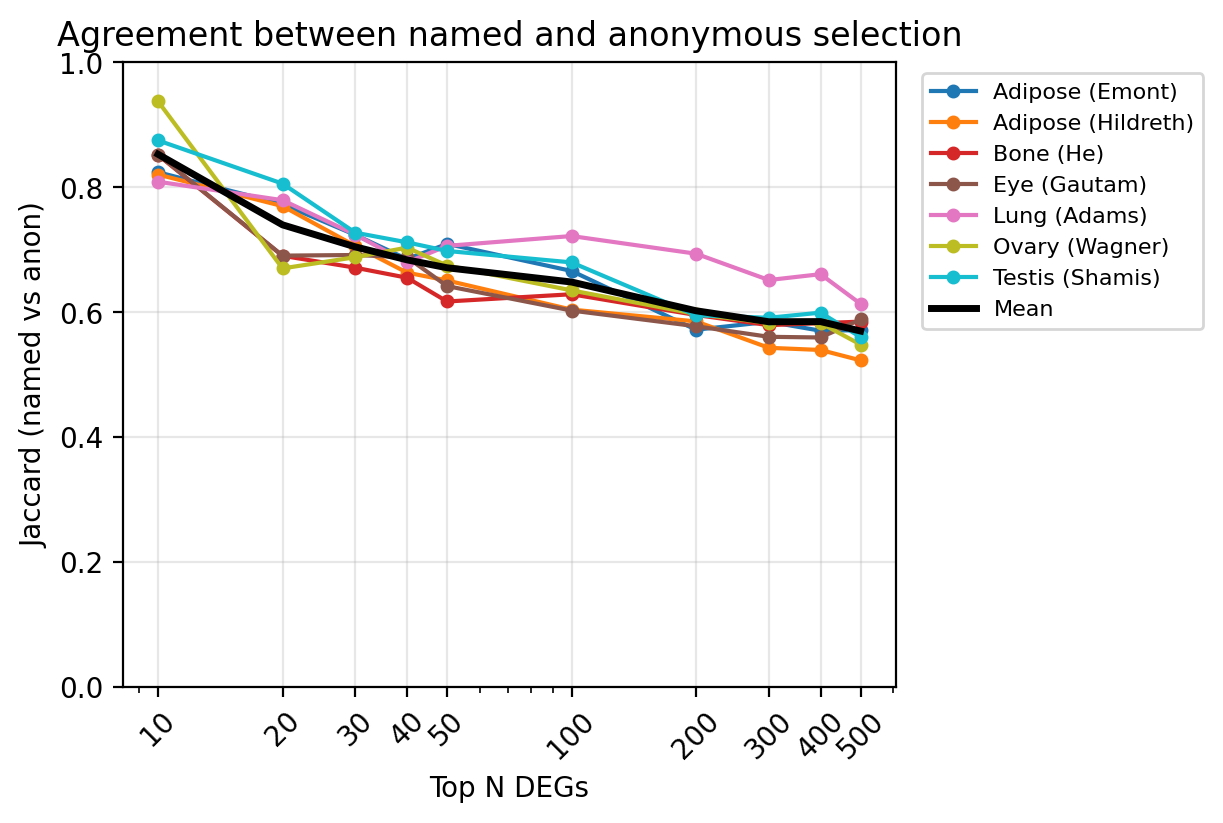

Mean Jaccard (named vs anon) across all N: 0.664

Mean Jaccard by N:
  N  jaccard
 10    0.853
 20    0.740
 30    0.705
 40    0.684
 50    0.671
100    0.648
200    0.602
300    0.585
400    0.585
500    0.570


In [8]:
# How much do named and anonymous agree with each other?
agree_rows = []
for ds in datasets:
    d = data[ds]
    for n in N_values:
        if n not in d['sel'] or n not in d['sel_anon']:
            continue
        named_pairs = build_pairs(d['sel'][n])
        anon_pairs = build_pairs(d['sel_anon'][n])
        if not named_pairs or not anon_pairs:
            continue
        overlap = len(named_pairs & anon_pairs)
        jaccard = overlap / len(named_pairs | anon_pairs)
        agree_rows.append({
            'dataset': ds, 'label': labels[ds], 'N': n,
            'named_pairs': len(named_pairs), 'anon_pairs': len(anon_pairs),
            'overlap': overlap, 'jaccard': jaccard,
        })

agree = pd.DataFrame(agree_rows)
agree_mean = agree.groupby('N')[['jaccard']].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
for i, ds in enumerate(datasets):
    sub = agree[agree['dataset'] == ds].sort_values('N')
    ax.plot(sub['N'], sub['jaccard'], 'o-', color=colors[i], label=labels[ds], markersize=4)
ax.plot(agree_mean['N'], agree_mean['jaccard'], 'k-', linewidth=2.5, label='Mean', zorder=10)
ax.set(xlabel='Top N DEGs', ylabel='Jaccard (named vs anon)', title='Agreement between named and anonymous selection')
ax.set_xscale('log')
ax.set_xticks(N_values)
ax.set_xticklabels([str(n) for n in N_values], rotation=45)
ax.set_ylim(0, 1)
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()

print(f"Mean Jaccard (named vs anon) across all N: {agree['jaccard'].mean():.3f}")
print()
print('Mean Jaccard by N:')
print(agree_mean.to_string(index=False, float_format='%.3f'))

# Figure 3: All methods comparison

Selection (named, best N) vs extraction vs generation, all against human curation.

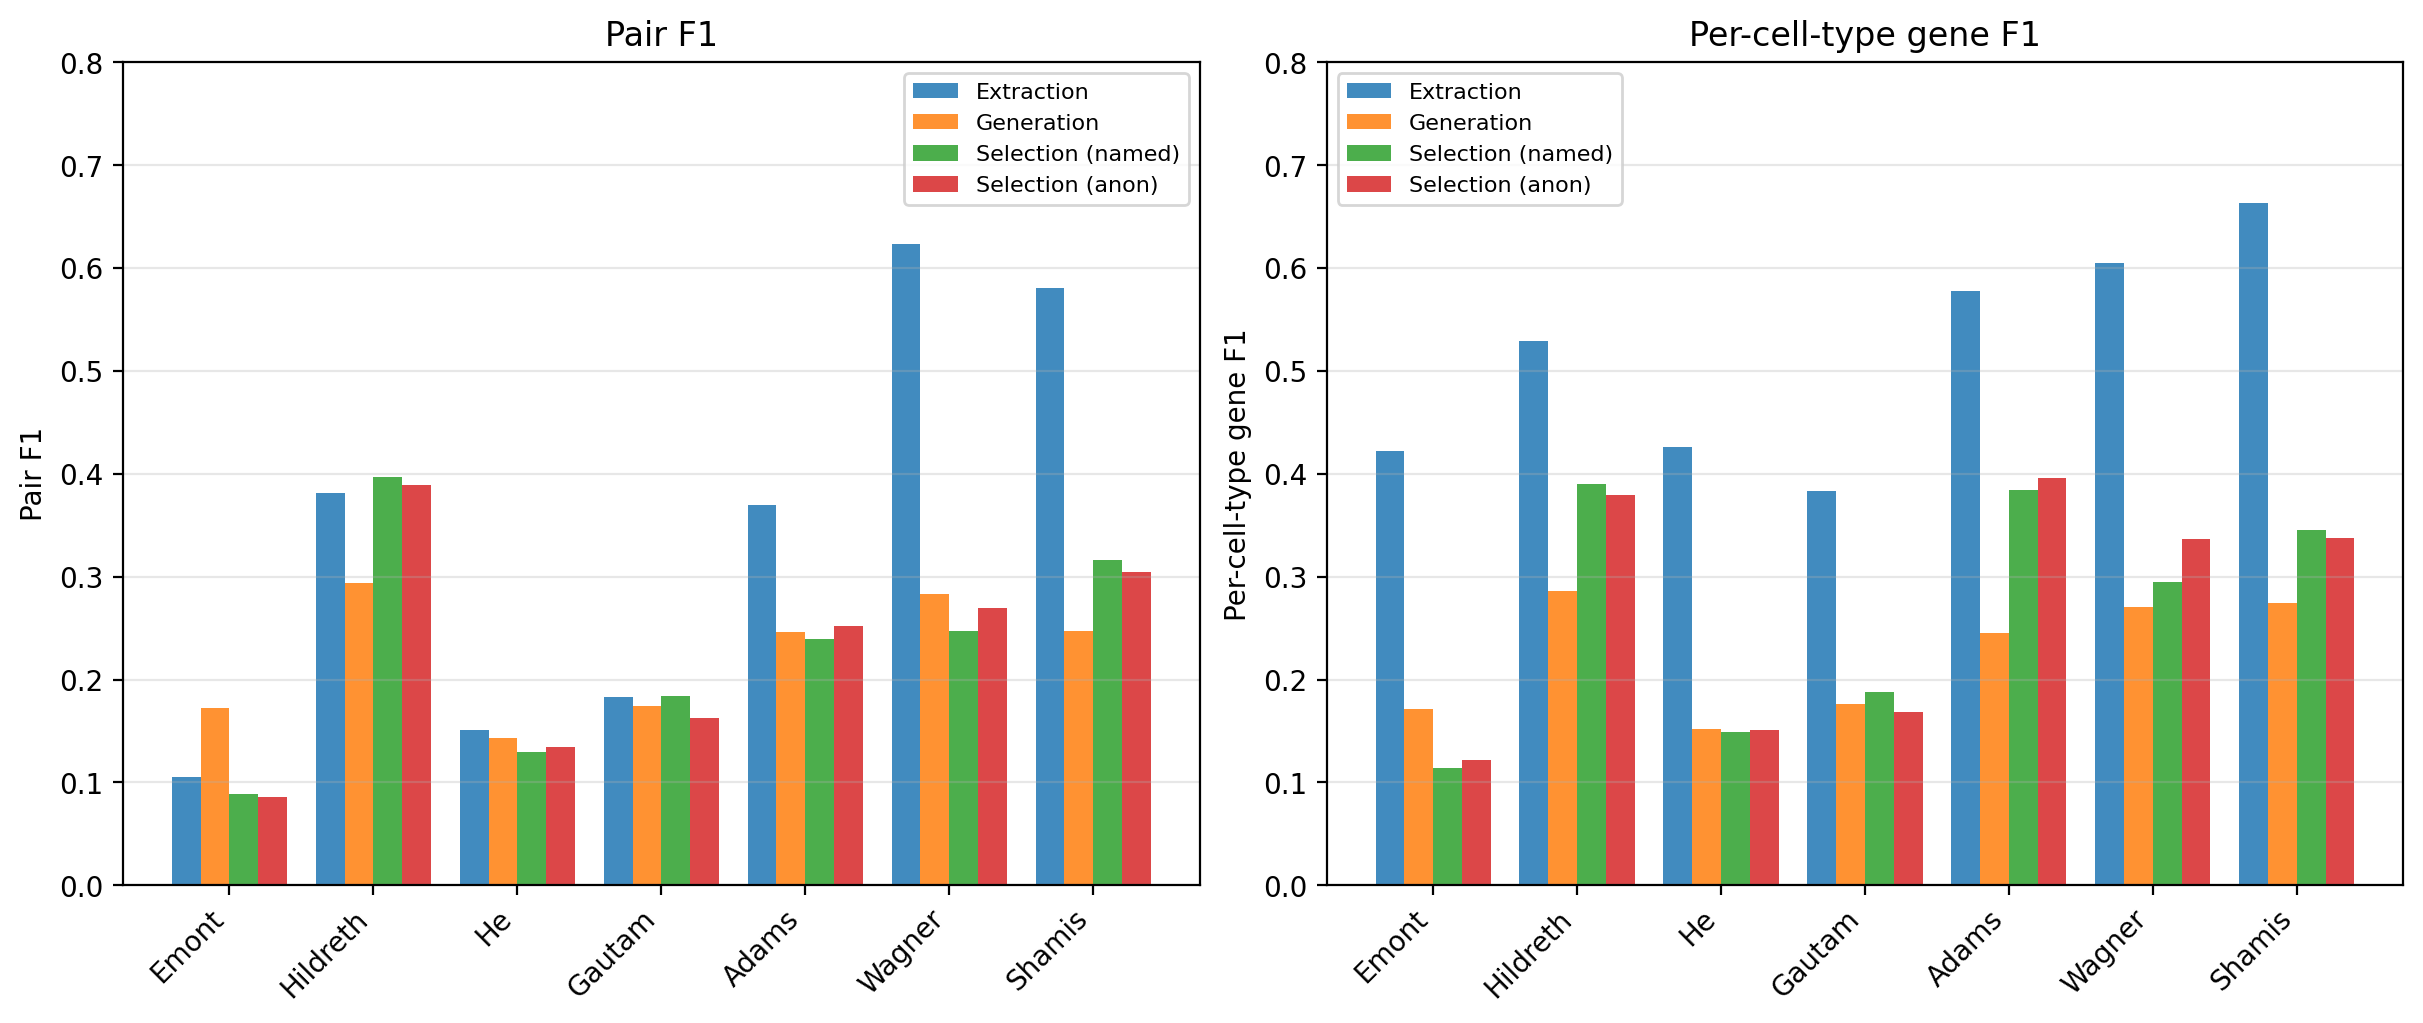

In [9]:
# Build comparison table: extraction, generation, named selection (best N), anon selection (best N)
best_named = named.loc[named.groupby('dataset')['pair_f1'].idxmax()]
anon = sweep[sweep['mode'] == 'anon']
best_anon = anon.loc[anon.groupby('dataset')['pair_f1'].idxmax()]

all_rows = []
for ds in datasets:
    d = data[ds]
    hmn_pairs = build_pairs(d['hmn'])
    hmn_groups = build_groups(d['hmn'])

    # Extraction
    ext_p, ext_r, ext_f1 = pair_metrics(build_pairs(d['llm']), hmn_pairs)
    ext_gf1, _ = per_celltype_gene_f1(build_groups(d['llm']), hmn_groups)

    # Generation
    gen_p, gen_r, gen_f1 = pair_metrics(build_pairs(d['gen']), hmn_pairs)
    gen_gf1, _ = per_celltype_gene_f1(build_groups(d['gen']), hmn_groups)

    # Named selection (best N)
    bn = best_named[best_named['dataset'] == ds].iloc[0]
    # Anon selection (best N)
    ba = best_anon[best_anon['dataset'] == ds].iloc[0]

    all_rows.append({
        'dataset': ds, 'label': labels[ds],
        'ext_pair_f1': ext_f1, 'ext_gene_f1': ext_gf1,
        'gen_pair_f1': gen_f1, 'gen_gene_f1': gen_gf1,
        'sel_pair_f1': bn['pair_f1'], 'sel_gene_f1': bn['gene_f1'], 'sel_N': int(bn['N']),
        'anon_pair_f1': ba['pair_f1'], 'anon_gene_f1': ba['gene_f1'], 'anon_N': int(ba['N']),
    })

cmp = pd.DataFrame(all_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

methods = ['ext', 'gen', 'sel', 'anon']
method_labels = ['Extraction', 'Generation', 'Selection (named)', 'Selection (anon)']
method_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for metric, ax, title in zip(
    ['pair_f1', 'gene_f1'],
    axes,
    ['Pair F1', 'Per-cell-type gene F1'],
):
    x = np.arange(len(cmp))
    width = 0.2
    for j, (method, mlabel, mcolor) in enumerate(zip(methods, method_labels, method_colors)):
        col = f'{method}_{metric}'
        ax.bar(x + j * width, cmp[col].values, width, label=mlabel, color=mcolor, alpha=0.85)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels([l.split('(')[1].rstrip(')') for l in cmp['label']], rotation=45, ha='right')
    ax.set_ylim(0, 0.8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.savefig('figures/fig_all_methods.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [10]:
# Summary table for tex
print(f"{'Method':<25} {'Pair F1':>8} {'Gene F1':>8}")
print('-' * 45)
print(f"{'Extraction':<25} {cmp['ext_pair_f1'].mean():>8.3f} {cmp['ext_gene_f1'].mean():>8.3f}")
print(f"{'Generation':<25} {cmp['gen_pair_f1'].mean():>8.3f} {cmp['gen_gene_f1'].mean():>8.3f}")
print(f"{'Selection (named)':<25} {cmp['sel_pair_f1'].mean():>8.3f} {cmp['sel_gene_f1'].mean():>8.3f}")
print(f"{'Selection (anon)':<25} {cmp['anon_pair_f1'].mean():>8.3f} {cmp['anon_gene_f1'].mean():>8.3f}")
print()
print('Per-dataset detail:')
print(cmp[['label', 'ext_pair_f1', 'gen_pair_f1', 'sel_pair_f1', 'sel_N', 'anon_pair_f1', 'anon_N']].to_string(index=False, float_format='%.3f'))

Method                     Pair F1  Gene F1
---------------------------------------------
Extraction                   0.342    0.515
Generation                   0.223    0.225
Selection (named)            0.229    0.266
Selection (anon)             0.228    0.270

Per-dataset detail:
             label  ext_pair_f1  gen_pair_f1  sel_pair_f1  sel_N  anon_pair_f1  anon_N
   Adipose (Emont)        0.105        0.172        0.089     50         0.086      20
Adipose (Hildreth)        0.382        0.294        0.397    100         0.389     100
         Bone (He)        0.151        0.143        0.130    300         0.134     300
      Eye (Gautam)        0.183        0.174        0.184     50         0.163      50
      Lung (Adams)        0.370        0.247        0.239    400         0.252     400
    Ovary (Wagner)        0.624        0.283        0.247    100         0.270     400
   Testis (Shamis)        0.580        0.248        0.317    300         0.305     300


# Figure 4: Number of markers selected

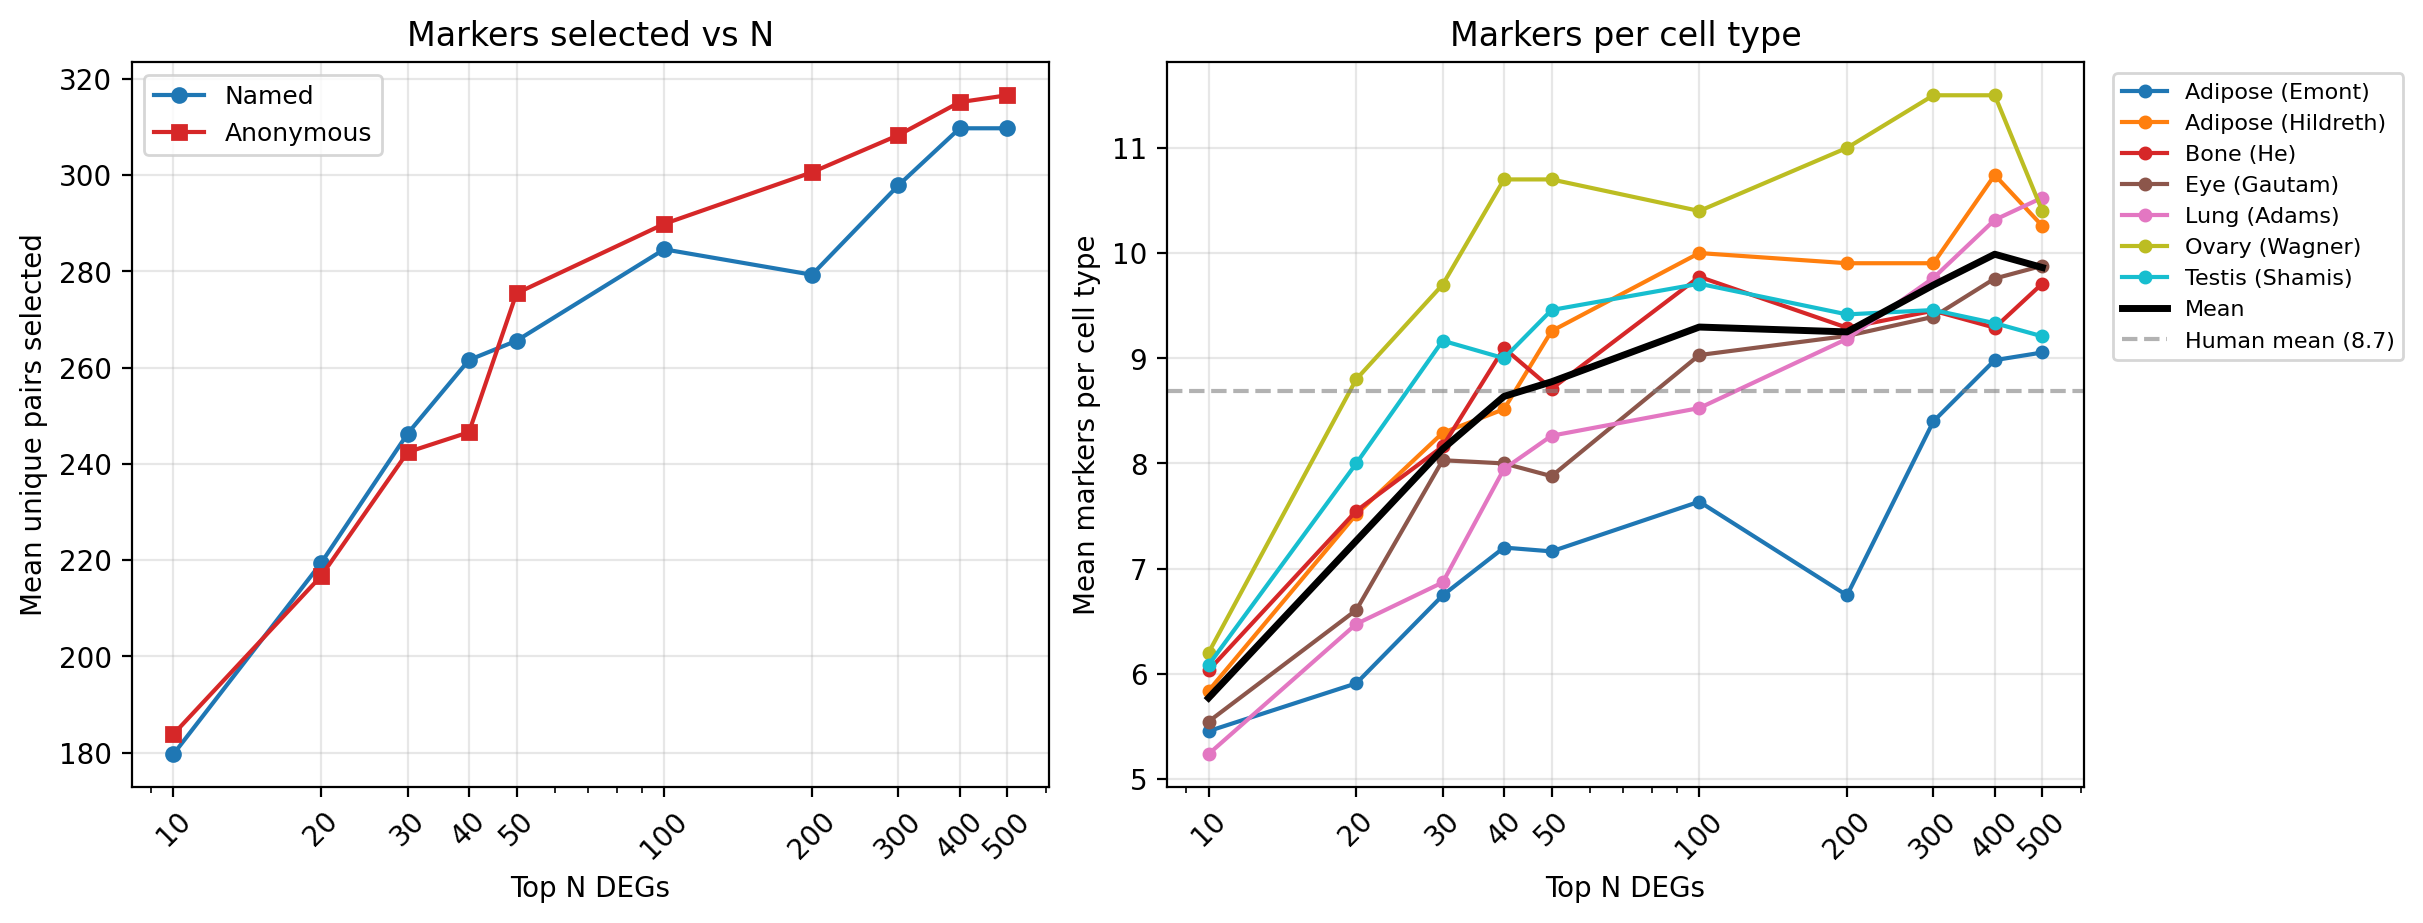

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Left: named vs anon total pairs vs N (means)
ax = axes[0]
ax.plot(named_mean['N'], named_mean['n_selected'], 'o-', color='tab:blue', label='Named', markersize=5)
ax.plot(anon_mean['N'], anon_mean['n_selected'], 's-', color='tab:red', label='Anonymous', markersize=5)
ax.set(xlabel='Top N DEGs', ylabel='Mean unique pairs selected', title='Markers selected vs N')
ax.set_xscale('log')
ax.set_xticks(N_values)
ax.set_xticklabels([str(n) for n in N_values], rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: markers per cell type (named only)
ax = axes[1]
mpc_rows = []
for _, row in named.iterrows():
    ds, n = row['dataset'], row['N']
    if n in data[ds]['sel']:
        groups = build_groups(data[ds]['sel'][n])
        mpc_rows.append({'N': n, 'dataset': ds, 'mpc': np.mean([len(v) for v in groups.values()]) if groups else 0})
mpc = pd.DataFrame(mpc_rows)
for i, ds in enumerate(datasets):
    sub = mpc[mpc['dataset'] == ds].sort_values('N')
    ax.plot(sub['N'], sub['mpc'], 'o-', color=colors[i], label=labels[ds], markersize=4)
mpc_mean = mpc.groupby('N')['mpc'].mean().reset_index()
ax.plot(mpc_mean['N'], mpc_mean['mpc'], 'k-', linewidth=2.5, label='Mean', zorder=10)

hmn_mpc = np.mean([np.mean([len(v) for v in build_groups(data[ds]['hmn']).values()]) for ds in datasets])
ax.axhline(hmn_mpc, color='gray', linestyle='--', alpha=0.6, label=f'Human mean ({hmn_mpc:.1f})')

ax.set(xlabel='Top N DEGs', ylabel='Mean markers per cell type', title='Markers per cell type')
ax.set_xscale('log')
ax.set_xticks(N_values)
ax.set_xticklabels([str(n) for n in N_values], rotation=45)
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.show()

# Summary: mean metrics by N

In [12]:
for mode_label, mode_key in [('Named', 'named'), ('Anonymous', 'anon')]:
    sub = sweep[sweep['mode'] == mode_key]
    tbl = sub.groupby('N').agg({
        'n_selected': 'mean', 'pair_precision': 'mean', 'pair_recall': 'mean',
        'pair_f1': 'mean', 'gene_f1': 'mean', 'gene_jaccard': 'mean',
        'upper_bound_recall': 'mean',
    }).round(3)
    tbl.columns = ['Avg pairs', 'Precision', 'Recall', 'Pair F1', 'Gene F1', 'Jaccard', 'UB Recall']
    print(f'\n{mode_label} selection (mean across datasets):')
    print(tbl.to_string())


Named selection (mean across datasets):
     Avg pairs  Precision  Recall  Pair F1  Gene F1  Jaccard  UB Recall
N                                                                      
10     179.714      0.183   0.158    0.167    0.184    0.158      0.173
20     219.429      0.177   0.195    0.182    0.204    0.166      0.234
30     246.286      0.181   0.225    0.197    0.221    0.172      0.288
40     261.571      0.181   0.235    0.201    0.225    0.181      0.314
50     265.571      0.181   0.242    0.203    0.231    0.181      0.337
100    284.571      0.186   0.267    0.215    0.245    0.190      0.417
200    279.286      0.192   0.281    0.222    0.260    0.197      0.502
300    297.857      0.190   0.287    0.223    0.259    0.199      0.548
400    309.714      0.188   0.296    0.223    0.262    0.199      0.581
500    309.714      0.185   0.284    0.218    0.253    0.196      0.598

Anonymous selection (mean across datasets):
     Avg pairs  Precision  Recall  Pair F1  Gene F

# Cost

In [13]:
cost_rows = []
for ds in datasets:
    base = Path(f'../data/{ds}/evidence_selected')
    for prefix, mode in [('metrics_top', 'named'), ('metrics_anon_top', 'anon')]:
        for n in N_values:
            mf = base / f'{prefix}{n}.json'
            if mf.exists():
                m = json.load(open(mf))
                cost_rows.append({
                    'dataset': labels[ds], 'mode': mode, 'N': n,
                    'input_tokens': m['input_tokens'],
                    'output_tokens': m['output_tokens'],
                    'total_cost': m['total_cost'],
                    'time_sec': m['processing_time_sec'],
                })

costs = pd.DataFrame(cost_rows)

for mode in ['named', 'anon']:
    sub = costs[costs['mode'] == mode]
    print(f'{mode.capitalize()} selection:')
    print(f'  Total cost: ${sub["total_cost"].sum():.2f}')
    print(f'  Total tokens: {sub["input_tokens"].sum():,} in + {sub["output_tokens"].sum():,} out')
    print(f'  Total time: {sub["time_sec"].sum()/60:.1f} min')
    print()

Named selection:
  Total cost: $42.87
  Total tokens: 3,491,023 in + 1,016,645 out
  Total time: 232.9 min

Anon selection:
  Total cost: $39.47
  Total tokens: 3,342,480 in + 910,273 out
  Total time: 208.8 min



# Figure 3 (paper): Summary of LLM marker curation methods

Four-panel comparison of generation, selection (best N), and extraction:
(a) number of markers, (b) pair F1, (c) cost, (d) time.

In [14]:
# Gather per-dataset metrics for all three methods
# Selection: use best N per dataset (by named pair F1)
# Generation & Selection: evaluated against ALL human annotations
# Extraction: evaluated against TEXT-ONLY human annotations (since it only processes text)
best_named = named.loc[named.groupby('dataset')['pair_f1'].idxmax()]

fig3_rows = []
for ds in datasets:
    d = data[ds]
    hmn_pairs_all = build_pairs(d['hmn'])

    # Text-only human annotations for extraction comparison
    hmn_txt = d['hmn'][d['hmn']['source_type'].str.contains('text', case=False, na=False)]
    hmn_pairs_txt = build_pairs(hmn_txt)

    # --- Generation (vs all human) ---
    gen_pairs = build_pairs(d['gen'])
    _, _, gen_f1 = pair_metrics(gen_pairs, hmn_pairs_all)
    gen_n = len(gen_pairs)
    mf = Path(f'../data/{ds}/evidence_generated/metrics.json')
    gm = json.load(open(mf)) if mf.exists() else {}
    gen_cost = gm.get('total_cost', 0)
    gen_time = gm.get('processing_time_sec', 0) / 60

    # --- Selection (best N, vs all human) ---
    bn = best_named[best_named['dataset'] == ds].iloc[0]
    sel_n = int(bn['n_selected'])
    sel_f1 = bn['pair_f1']
    best_n_val = int(bn['N'])
    mf = Path(f'../data/{ds}/evidence_selected/metrics_top{best_n_val}.json')
    sm = json.load(open(mf)) if mf.exists() else {}
    sel_cost = sm.get('total_cost', 0)
    sel_time = sm.get('processing_time_sec', 0) / 60

    # --- Extraction (vs text-only human) ---
    ext_pairs = build_pairs(d['llm'])
    _, _, ext_f1 = pair_metrics(ext_pairs, hmn_pairs_txt)
    ext_n = len(ext_pairs)
    mf = Path(f'../data/{ds}/evidence_llm/metrics.json')
    em = json.load(open(mf)) if mf.exists() else {}
    ext_cost = em.get('total_cost', 0)
    ext_time = em.get('processing_time_sec', 0) / 60

    fig3_rows.append({
        'dataset': ds, 'label': labels[ds],
        'gen_n': gen_n, 'gen_f1': gen_f1, 'gen_cost': gen_cost, 'gen_time': gen_time,
        'sel_n': sel_n, 'sel_f1': sel_f1, 'sel_cost': sel_cost, 'sel_time': sel_time,
        'ext_n': ext_n, 'ext_f1': ext_f1, 'ext_cost': ext_cost, 'ext_time': ext_time,
    })

fig3 = pd.DataFrame(fig3_rows)

# Print summary
print('Per-dataset summary (cost from metrics.json):')
print('  Generation & Selection: vs ALL human annotations')
print('  Extraction: vs TEXT-ONLY human annotations')
print()
print(fig3[['label', 'gen_n', 'sel_n', 'ext_n', 'gen_f1', 'sel_f1', 'ext_f1',
            'gen_cost', 'sel_cost', 'ext_cost', 'gen_time', 'sel_time', 'ext_time']].to_string(
    index=False, float_format='%.2f'))
print()
print('Totals / means:')
for method in ['gen', 'sel', 'ext']:
    n = fig3[f'{method}_n'].mean()
    f1 = fig3[f'{method}_f1'].mean()
    cost = fig3[f'{method}_cost'].sum()
    time = fig3[f'{method}_time'].sum()
    print(f'  {method}: N={n:.0f}, F1={f1:.3f}, cost=${cost:.2f}, time={time:.1f} min')

Per-dataset summary (cost from metrics.json):
  Generation & Selection: vs ALL human annotations
  Extraction: vs TEXT-ONLY human annotations

             label  gen_n  sel_n  ext_n  gen_f1  sel_f1  ext_f1  gen_cost  sel_cost  ext_cost  gen_time  sel_time  ext_time
   Adipose (Emont)    317    394     34    0.17    0.09    0.62      0.49      0.86      0.29      3.20     16.17      1.32
Adipose (Hildreth)    249    310     70    0.29    0.40    0.79      0.41      0.77      0.57      2.80      3.47      2.62
         Bone (He)    203    293     40    0.14    0.13    0.45      0.34      0.95      0.81      2.31      3.40      3.67
      Eye (Gautam)    243    260     44    0.17    0.18    0.65      0.39      0.58      0.38      2.59      3.15      1.69
      Lung (Adams)    165    392     49    0.25    0.24    0.80      0.30      0.87      0.55      2.02      4.79      1.94
    Ovary (Wagner)     69    104     35    0.28    0.25    0.81      0.12      0.26      0.28      0.82      1.35

Saved figures/fig_llm_curation.pdf


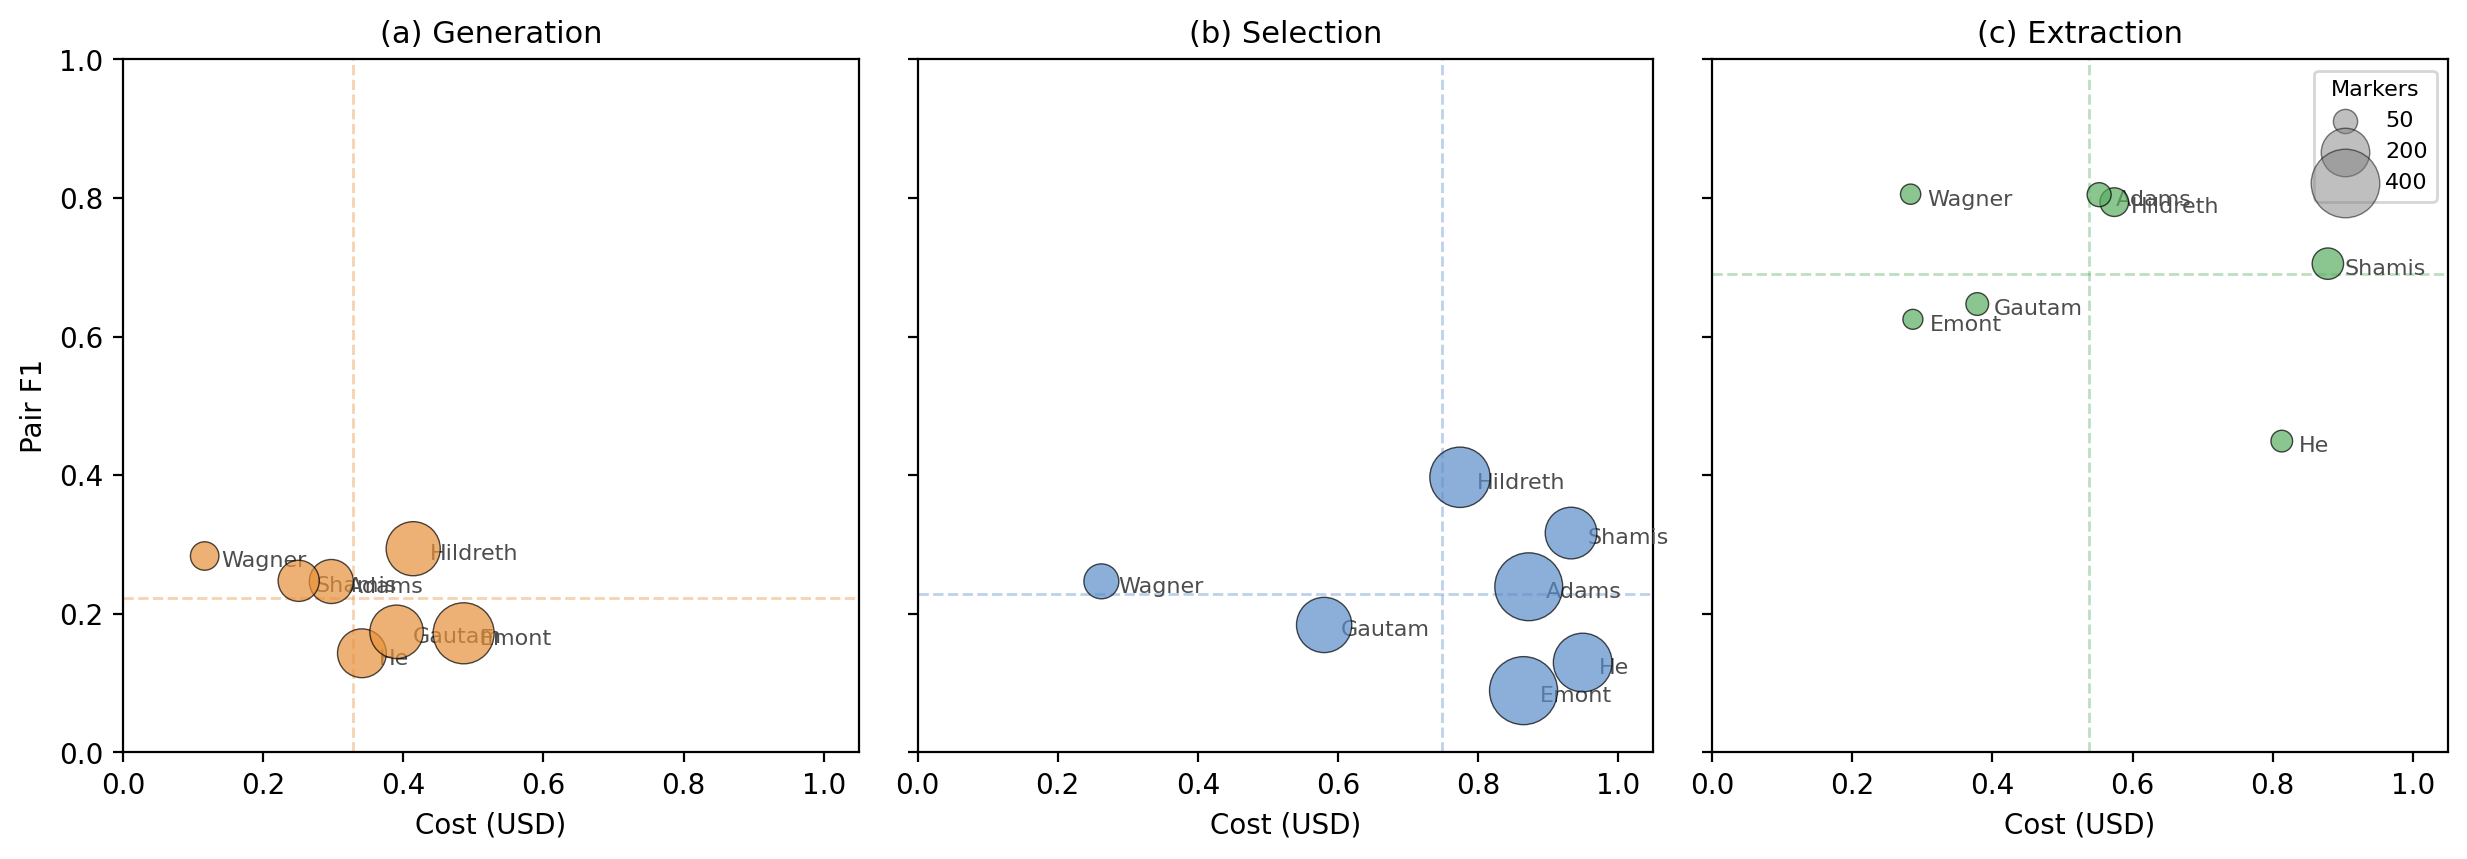

In [15]:
# Figure 3: Summary of LLM marker curation methods
# Three scatter plots (one per method), shared axes
# x = cost, y = pair F1, size = number of markers

short = {
    'adipose_Emont2022': 'Emont',
    'adipose_Hildreth2021': 'Hildreth',
    'bone_He2021': 'He',
    'eye_Gautam2021': 'Gautam',
    'lung_Adams2020': 'Adams',
    'ovary_Wagner2020': 'Wagner',
    'testis_Shamis2020': 'Shamis',
}

method_names = ['Generation', 'Selection', 'Extraction']
method_keys = ['gen', 'sel', 'ext']
method_colors = ['#E8913A', '#5B8DC9', '#5AAE61']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.08)

# Global ranges for consistent sizing and axes
all_n = np.concatenate([fig3[f'{mk}_n'].values for mk in method_keys])
size_scale = 600 / all_n.max()

all_costs = np.concatenate([fig3[f'{mk}_cost'].values for mk in method_keys])
x_max = np.ceil(all_costs.max() * 10) / 10 + 0.05  # round up with padding

for ax, mk, mn, mc in zip(axes, method_keys, method_names, method_colors):
    costs = fig3[f'{mk}_cost'].values
    f1s = fig3[f'{mk}_f1'].values
    ns = fig3[f'{mk}_n'].values
    sizes = ns * size_scale

    ax.scatter(costs, f1s, s=sizes, color=mc, alpha=0.7,
               edgecolors='black', linewidth=0.5, zorder=5)

    # Label each point
    for i, ds in enumerate(datasets):
        ax.annotate(short[ds], (costs[i], f1s[i]),
                    textcoords='offset points', xytext=(6, -4),
                    fontsize=8, color='0.3')

    # Mean crosshair
    mean_cost = costs.mean()
    mean_f1 = f1s.mean()
    ax.axhline(mean_f1, color=mc, linestyle='--', alpha=0.4, linewidth=1)
    ax.axvline(mean_cost, color=mc, linestyle='--', alpha=0.4, linewidth=1)

    ax.set_title(f'({chr(97+list(method_keys).index(mk))}) {mn}', fontsize=11)
    ax.set_xlabel('Cost (USD)')
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 1)

axes[0].set_ylabel('Pair F1')

# Size legend
for n_ref in [50, 200, 400]:
    axes[2].scatter([], [], s=n_ref * size_scale, color='gray', alpha=0.5,
                    edgecolors='black', linewidth=0.5, label=f'{n_ref}')
axes[2].legend(fontsize=8, loc='upper right', title='Markers', title_fontsize=8)

plt.savefig('figures/fig_llm_curation.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/fig_llm_curation.png', bbox_inches='tight', dpi=150)
print('Saved figures/fig_llm_curation.pdf')
plt.show()